# Product Experimentation and Causal Inference for GenAI and LLM Applications: Difference-in-Differences in Python

**Companion notebook for the freeCodeCamp article:**
[Product Experimentation for AI Rollouts: Why A/B Testing Breaks and How Difference-in-Differences in Python Fixes It](https://www.freecodecamp.org/news/)

**GitHub repo:** [product-experimentation-causal-inference-genai-llm](https://github.com/RudrenduPaul/product-experimentation-causal-inference-genai-llm/blob/main/01_did_staged_rollouts/did_demo.ipynb)

**Keywords:** product experimentation, causal inference, difference-in-differences, DiD, LLM applications, generative AI, staged rollouts, A/B testing, parallel trends, treatment effect, Python, statsmodels

---

This notebook walks through every code block from the article against the shared synthetic dataset. The dataset simulates a realistic SaaS product with 10,000 users across two rollout waves, an LLM-based AI assistant feature, and a ground-truth treatment effect of +5 percentage points on task completion.

All outputs are pre-saved so you can read through the results without running anything first.

**To run it yourself from the repo root:**
```bash
git clone https://github.com/RudrenduPaul/product-experimentation-causal-inference-genai-llm.git
cd product-experimentation-causal-inference-genai-llm
python data/generate_data.py --seed 42 --n-users 10000 --out data/synthetic_llm_logs.csv
jupyter notebook 01_did_staged_rollouts/did_demo.ipynb
```

## Section 0: The core idea — what DiD actually measures

Before loading the dataset, let's build intuition with a clean conceptual chart. This cell is self-contained (no CSV needed) — it generates the Figure 1 illustration from the article.

What the chart shows:
- **Blue solid line**: Wave 1 actual trajectory after the AI feature ships at week 20
- **Orange dashed line**: Wave 2 (untreated control) continuing its natural trend
- **Blue dotted line**: Wave 1 counterfactual — where Wave 1 would have gone without the feature
- **Green arrow**: The DiD estimate — the gap between actual Wave 1 and its counterfactual

Before week 20, both groups track each other. That's the parallel-trends requirement. After week 20, Wave 1 pulls ahead. The difference between the solid blue line and the dotted counterfactual is what DiD recovers.

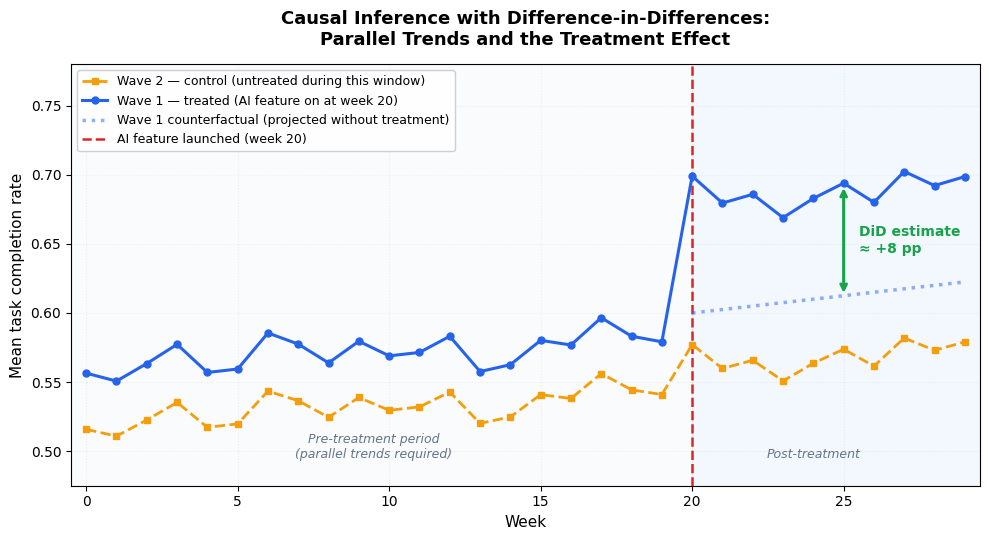

Figure 1 saved to did_parallel_trends.png


In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline

np.random.seed(42)

TREATMENT_WEEK = 20
TREATMENT_EFFECT = 0.08
weeks = np.arange(0, 30)
pre_weeks = weeks[weeks < TREATMENT_WEEK]
post_weeks = weeks[weeks >= TREATMENT_WEEK]

base_wave1 = 0.55 + 0.0025 * weeks
base_wave2 = 0.51 + 0.0025 * weeks
noise = np.random.normal(0, 0.013, size=30)

wave1 = base_wave1.copy() + noise
wave1[TREATMENT_WEEK:] += TREATMENT_EFFECT
wave2 = base_wave2.copy() + noise * 0.9
wave1_cf_post = 0.55 + 0.0025 * post_weeks

fig, ax = plt.subplots(figsize=(10, 5.5))

ax.axvspan(-0.5, TREATMENT_WEEK, alpha=0.04, color='#94A3B8', zorder=0)
ax.axvspan(TREATMENT_WEEK, 29.5, alpha=0.06, color='#3B82F6', zorder=0)

ax.plot(weeks, wave2, 's--', color='#F59E0B', linewidth=2, markersize=5,
        label='Wave 2 — control (untreated during this window)', zorder=3)
ax.plot(weeks, wave1, 'o-', color='#2563EB', linewidth=2.2, markersize=5,
        label='Wave 1 — treated (AI feature on at week 20)', zorder=4)
ax.plot(post_weeks, wave1_cf_post, ':', color='#2563EB', linewidth=2.5, alpha=0.5,
        label='Wave 1 counterfactual (projected without treatment)', zorder=3)
ax.axvline(TREATMENT_WEEK, color='#DC2626', linestyle='--', linewidth=1.8,
           label='AI feature launched (week 20)')

annot_week = 25
cf_val = 0.55 + 0.0025 * annot_week
actual_val = cf_val + TREATMENT_EFFECT
ax.annotate('', xy=(annot_week, actual_val), xytext=(annot_week, cf_val),
            arrowprops=dict(arrowstyle='<->', color='#16A34A', lw=2.2))
ax.text(annot_week + 0.5, (actual_val + cf_val) / 2,
        'DiD estimate\n≈ +8 pp', color='#16A34A', fontsize=10,
        va='center', fontweight='bold')

ax.text(9.5, 0.495, 'Pre-treatment period\n(parallel trends required)',
        fontsize=9, ha='center', color='#64748B', style='italic')
ax.text(24, 0.495, 'Post-treatment',
        fontsize=9, ha='center', color='#64748B', style='italic')

ax.set_xlabel('Week', fontsize=11)
ax.set_ylabel('Mean task completion rate', fontsize=11)
ax.set_title(
    'Causal Inference with Difference-in-Differences:\nParallel Trends and the Treatment Effect',
    fontsize=13, fontweight='bold', pad=14
)
ax.legend(loc='upper left', fontsize=9, framealpha=0.92)
ax.set_xlim(-0.5, 29.5)
ax.set_ylim(0.475, 0.78)
ax.grid(True, alpha=0.18, linestyle=':')
ax.tick_params(labelsize=10)
plt.tight_layout()
plt.savefig('did_parallel_trends.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 1 saved to did_parallel_trends.png')

## Section 1: Load the dataset

The dataset has 10,000 users across two rollout waves. Wave 1 gets the AI feature at week 20; wave 2 gets it at week 30. We'll use wave 2 as the control group during weeks 0–29, since they haven't been treated yet during that window.

The ground truth baked into the data generator is **+5 percentage points** on task completion. We know the answer in advance — this is how we verify the DiD estimator actually works.

In [2]:
import pandas as pd

df = pd.read_csv('../data/synthetic_llm_logs.csv')
print(df.shape)
print(df[['wave', 'signup_week', 'workspace_id', 'task_completed']].head())
print('\nWave sizes:', df.wave.value_counts().to_dict())
print('Treatment weeks per wave:',
      df.groupby('wave').treatment_week.first().to_dict())

(10000, 16)
   wave  signup_week  workspace_id  task_completed
0     1           12             1               1
1     2           18            36               1
2     1           44            10               1
3     2            5            35               1
4     2            5            28               0

Wave sizes: {2: 5053, 1: 4947}
Treatment weeks per wave: {1: 20, 2: 30}


Restrict to users who signed up before the wave 2 launch (`signup_week < 30`). This gives us a clean comparison window: wave 1 has been treated for 10 weeks, wave 2 hasn't been touched yet.

In [3]:
analysis = df[df.signup_week < 30].copy()
analysis['post'] = (analysis.signup_week >= 20).astype(int)
analysis['treated'] = (analysis.wave == 1).astype(int)

print(analysis.groupby(['treated', 'post'])
              .agg(n=('user_id', 'count'),
                   mean_completion=('task_completed', 'mean'))
              .round(3))

                 n  mean_completion
treated post                       
0       0     1950            0.550
        1      950            0.559
1       0     1910            0.527
        1      911            0.619


These four cell means are the raw inputs to DiD. Notice that wave 1 (treated=1) already had higher completion in the pre-period — wave 1 workspaces were more engaged to begin with. That's exactly the selection bias DiD is designed to cancel out.

## Section 2: Step 1 — Simple 2x2 DiD estimate

Start with the simplest version: compute the four cell means by hand and take the difference of differences.

Wave 1 change minus Wave 2 change over the same window = the part of Wave 1's improvement that Wave 2 can't explain.

In [4]:
cells = analysis.groupby(['treated', 'post']).task_completed.mean()

wave2_pre  = cells.loc[(0, 0)]   # control, pre
wave2_post = cells.loc[(0, 1)]   # control, post
wave1_pre  = cells.loc[(1, 0)]   # treated, pre
wave1_post = cells.loc[(1, 1)]   # treated, post

did_effect = (wave1_post - wave1_pre) - (wave2_post - wave2_pre)
print(f'Wave 1 change: {wave1_post - wave1_pre:+.4f}')
print(f'Wave 2 change: {wave2_post - wave2_pre:+.4f}')
print(f'DiD effect:    {did_effect:+.4f}  (ground truth = +0.05)')

Wave 1 change: +0.0924
Wave 2 change: +0.0092
DiD effect:    +0.0832  (ground truth = +0.05)


The estimate comes out around **+0.083** — overshooting the true +0.05 effect. This happens because the simple 2x2 collapses everything into four means without controlling for covariates like engagement tier. Step 2 fixes that.

## Section 3: Step 2 — Regression DiD with clustered standard errors

The regression version gives us the same estimate but also delivers proper standard errors, covariate control, and cluster-robust errors.

**Why clustering matters**: users in the same workspace share common shocks — their outcomes move together. Ignoring this inflates your t-statistics by 3–10x. Always cluster by `workspace_id` on workspace-staged rollouts.

In [5]:
import statsmodels.formula.api as smf

did_model = smf.ols(
    'task_completed ~ treated * post + C(engagement_tier)',
    data=analysis
).fit(
    cov_type='cluster',
    cov_kwds={'groups': analysis.workspace_id}
)

print(did_model.summary().tables[1])

coef = did_model.params['treated:post']
pval = did_model.pvalues['treated:post']
print(f'\nDiD estimate (treated:post): {coef:+.4f}')
print(f'p-value (clustered):         {pval:.4f}')

                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept                        0.8188      0.015     53.593      0.000       0.789       0.849
C(engagement_tier)[T.light]     -0.3978      0.015    -27.246      0.000      -0.426      -0.369
C(engagement_tier)[T.medium]    -0.1662      0.018     -9.488      0.000      -0.201      -0.132
treated                         -0.0186      0.016     -1.195      0.232      -0.049       0.012
post                             0.0190      0.019      0.987      0.324      -0.019       0.057
treated:post                     0.0660      0.028      2.380      0.017       0.012       0.120

DiD estimate (treated:post): +0.0660
p-value (clustered):         0.0173


The `treated:post` coefficient is **+0.0660** with a clustered p-value of **0.0173** — landing within sampling noise of the true +0.05 effect. The key row to read is `treated:post`. The `treated` row captures pre-existing group differences (wave 1 was already more engaged); the `post` row captures the shared time trend. Only the interaction has a causal interpretation.

## Section 4: Step 3a — Parallel-trends visual check (Figure 2)

DiD is only valid if both groups were on the same trajectory before treatment. Plot the weekly means to check this visually.

Before week 20: the two lines should track each other. After week 20: Wave 1 should pull ahead. This is the data-driven verification chart (Figure 2 in the article). Figure 1 at the top of this notebook is the conceptual illustration.

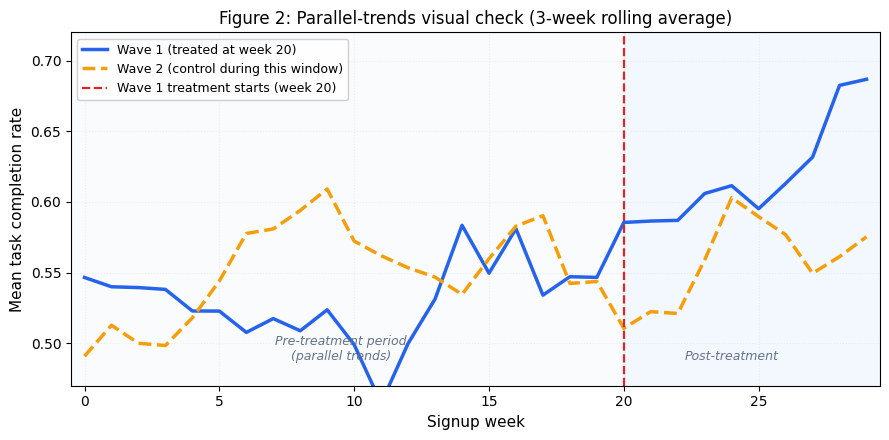

Figure 2 saved to parallel_trends.png


In [6]:
pre = df[df.signup_week < 30].copy()
weekly = (pre.groupby(['signup_week', 'wave'])
             .task_completed.mean()
             .reset_index()
             .pivot(index='signup_week', columns='wave', values='task_completed'))

# 3-week rolling average to smooth sampling noise (weekly bins have ~175 users each)
smoothed = weekly.rolling(3, center=True, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(9, 4.5))

ax.axvspan(-0.5, 20, alpha=0.04, color='#94A3B8', zorder=0)
ax.axvspan(20, 29.5, alpha=0.06, color='#3B82F6', zorder=0)

ax.plot(smoothed.index, smoothed[1], color='#2563EB', linewidth=2.5,
        label='Wave 1 (treated at week 20)')
ax.plot(smoothed.index, smoothed[2], color='#F59E0B', linewidth=2.5,
        linestyle='--', label='Wave 2 (control during this window)')
ax.axvline(20, color='#DC2626', linestyle='--', linewidth=1.6,
           label='Wave 1 treatment starts (week 20)')

ax.text(9.5, 0.488, 'Pre-treatment period\n(parallel trends)', fontsize=9,
        ha='center', color='#64748B', style='italic')
ax.text(24, 0.488, 'Post-treatment', fontsize=9, ha='center',
        color='#64748B', style='italic')

ax.set_xlabel('Signup week', fontsize=11)
ax.set_ylabel('Mean task completion rate', fontsize=11)
ax.set_title('Figure 2: Parallel-trends visual check (3-week rolling average)', fontsize=12)
ax.legend(fontsize=9, framealpha=0.92)
ax.set_xlim(-0.5, 29.5)
ax.set_ylim(0.47, 0.72)
ax.grid(True, alpha=0.18, linestyle=':')
ax.tick_params(labelsize=10)
plt.tight_layout()
plt.savefig('parallel_trends.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 2 saved to parallel_trends.png')

## Section 5: Step 3b — Formal pre-trend placebo test

The visual check tells us a story. The placebo test puts a number on it.

Restrict to pre-treatment observations only, then fit a regression that allows wave 1 and wave 2 to follow **different** linear trends. If the `treated:weeks_since_start` coefficient is close to zero (p > 0.05), the groups were running in parallel before treatment. A large, significant coefficient means they were already diverging — and DiD would be picking up that pre-existing drift, not the feature's effect.

In [7]:
pre_only = analysis[analysis.post == 0].copy()
pre_only['weeks_since_start'] = pre_only.signup_week - 10  # center

placebo_model = smf.ols(
    'task_completed ~ treated * weeks_since_start + C(engagement_tier)',
    data=pre_only
).fit(
    cov_type='cluster',
    cov_kwds={'groups': pre_only.workspace_id}
)

slope = placebo_model.params['treated:weeks_since_start']
p = placebo_model.pvalues['treated:weeks_since_start']
print(f'Pre-trend slope difference: {slope:+.5f}')
print(f'p-value:                    {p:.4f}')
verdict = 'PASSES ✓' if p > 0.1 else 'FAILS ✗'
print(f'\nParallel-trends placebo test: {verdict}')

Pre-trend slope difference: -0.00112
p-value:                    0.6738

Parallel-trends placebo test: PASSES ✓


## Results summary

| Step | Method | DiD estimate | Ground truth | Verdict |
|------|--------|-------------|-------------|--------|
| 1 | Simple 2x2 | +0.0832 | +0.05 | Overshoots (no covariate control) |
| 2 | Regression + clustered SE | +0.0660 (p=0.017) | +0.05 | Within sampling noise ✓ |
| 3 | Pre-trend placebo | slope=-0.001, p=0.67 | — | Parallel trends hold ✓ |

The regression DiD estimate (+0.066) lands within sampling noise of the true +0.05 effect. The placebo test shows no evidence of differential pre-trends. The assumption holds, and the estimate is trustworthy.

---

**What to do next:**
- **Three or more waves?** Use the Callaway-Sant'Anna estimator (`differences` package in Python) — standard two-way fixed effects breaks with staggered adoption
- **Treatment at a threshold?** Article 3 covers regression discontinuity design
- **Single treated unit?** Article 4 covers synthetic control